# Destination Country Ranking Layer (SIH Trade Intelligence Module)

## 1. Problem Definition & Operational Objective

When an Indian exporter specifies an export commodity (e.g., **Basmati Rice**, HS6 `100630`) and an intended shipment volume (e.g., **1,000 kg**), the system must rank the optimal destination countries for India's export of that product.

### Core Methodological Principles:
1. **Explainable Multi-Criteria Weighted Opportunity Engine**: In trade policy and international logistics, binary "success/failure" labels do not exist in historical customs records. We deploy an evidence-grounded Multi-Criteria Decision Analysis (MCDA) model:
   $$\text{Opportunity Score} = \text{Demand} (30\%) + \text{Growth} (20\%) + \text{Trade Access} (15\%) + \text{Capacity} (10\%) + \text{Logistics} (10\%) + \text{Buyers} (5\%) + \text{Stability} (5\%) + \text{Risk Adj} (5\%)$$
2. **Directional Provenance (India-as-Exporter)**: Analysis strictly isolates outbound trade flows where **India is origin exporter** and foreign partners are destination importers.
3. **High-Performance Parquet Storage**: Raw CSV records are converted to compressed, strongly typed Parquet (`data/processed/01_partner_discovery_india_as_exporter.parquet`) using PyArrow.
4. **Aggregate Filtering**: Non-sovereign aggregates (e.g., `WLD` World Total) are strictly filtered prior to ranking.
5. **Bounded Quantity Fit**: Requested volume modifies scale alignment without generating artificial demand.
6. **Regulatory Risk Integration**: Sanctions, OFAC listings, and SCOMET restrictions produce transparent penalties and alerts.

## 2. Imports & Runtime Environment

In [1]:
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root and src are importable
for path in ['.', '..', os.path.abspath('..'), os.path.abspath('.')]:
    if path not in sys.path:
        sys.path.insert(0, path)

from src.ranking import (
    ProductResolver,
    resolve_product,
    FeatureEngineer,
    DestinationRankingEngine,
    rank_export_destinations,
    DEFAULT_WEIGHTS,
    convert_raw_csv_to_parquet
)

warnings.filterwarnings('ignore')
print(f"Python Version: {sys.version.split()[0]}")
print(f"Pandas Version: {pd.__version__}")
print(f"NumPy Version: {np.__version__}")

Python Version: 3.13.1
Pandas Version: 3.0.5
NumPy Version: 2.5.2


## 3. Configuration & Weighting Schemes

In [2]:
# Visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Configured baseline weights
print("Configured Baseline MCDA Dimension Weights:")
for k, v in DEFAULT_WEIGHTS.items():
    print(f"  - {k.replace('_', ' ').title():20s}: {v*100:4.1f}%")
assert np.isclose(sum(DEFAULT_WEIGHTS.values()), 1.0), "Dimension weights must sum to 1.0"

Configured Baseline MCDA Dimension Weights:
  - Demand              : 30.0%
  - Growth              : 20.0%
  - Access              : 15.0%
  - Economic Capacity   : 10.0%
  - Logistics           : 10.0%
  - Buyer Ecosystem     :  5.0%
  - Stability           :  5.0%
  - Risk                :  5.0%


## 4. Raw CSV Ingestion

In [3]:
# Locate raw CSV provenance file
raw_csv_candidates = [
    "data/raw/01_partner_discovery_india_as_exporter_eda.csv",
    "data_pipeline/data/final_csv/01_partner_discovery_india_as_exporter_eda.csv",
    "backend/brain/data/final_csv/01_partner_discovery_eda.csv",
    "data_pipeline/data/final_csv/01_partner_discovery_eda.csv"
]
raw_csv_path = None
for p in raw_csv_candidates:
    if os.path.exists(p):
        raw_csv_path = p
        break

print(f"Raw CSV Source: {raw_csv_path}")
df_raw = pd.read_csv(raw_csv_path)
print(f"Raw Dataset Loaded: {len(df_raw):,} rows x {df_raw.shape[1]} columns")

Raw CSV Source: data/raw/01_partner_discovery_india_as_exporter_eda.csv
Raw Dataset Loaded: 1,408 rows x 42 columns


## 5. CSV to Columnar Parquet Conversion

In [4]:
# Deterministic conversion with strong typing
parquet_output_paths = [
    "data/processed/01_partner_discovery_india_as_exporter.parquet",
    "backend/brain/processed/01_partner_discovery_india_as_exporter.parquet"
]

df_clean = convert_raw_csv_to_parquet(
    raw_csv_path=raw_csv_path,
    output_parquet_paths=parquet_output_paths
)
print(f"Parquet Conversion Completed: {len(df_clean):,} records written to PyArrow Parquet format.")

[Ingestion] Reading raw CSV from: data/raw/01_partner_discovery_india_as_exporter_eda.csv
[Ingestion] Raw records: 1,408 rows, 42 columns
[Ingestion] Wrote Parquet analytical dataset to: data/processed/01_partner_discovery_india_as_exporter.parquet (168,790 bytes)


[Ingestion] Wrote Parquet analytical dataset to: backend/brain/processed/01_partner_discovery_india_as_exporter.parquet (168,790 bytes)


[Ingestion] Successfully verified Parquet dataset reload (1,408 rows, 65 columns).
Parquet Conversion Completed: 1,408 records written to PyArrow Parquet format.


## 6. Parquet Validation & Reload Integrity

In [5]:
# Validate Parquet reload
df_reloaded = pd.read_parquet(parquet_output_paths[0], engine='pyarrow')
assert len(df_reloaded) == len(df_raw), "Parquet row count mismatch!"
assert df_reloaded.shape[1] >= 40, "Parquet column count mismatch!"
print(f">> Parquet File Reload Verified: {len(df_reloaded):,} rows x {df_reloaded.shape[1]} columns")
print(f"Parquet File Size: {os.path.getsize(parquet_output_paths[0]):,} bytes")

>> Parquet File Reload Verified: 1,408 rows x 65 columns
Parquet File Size: 168,790 bytes


## 7. Dataset Audit & Schema Summary

In [6]:
# Comprehensive audit summary
print("=== COMPREHENSIVE DATASET AUDIT ===")
print(f"Total Rows:                   {len(df_clean):,}")
print(f"Total Columns:                {df_clean.shape[1]}")
print(f"Temporal Coverage:            {df_clean['year'].min()} - {df_clean['year'].max()} ({df_clean['year'].nunique()} years)")
print(f"Origin Exporter:              {df_clean['exporter_iso3'].unique().tolist()} (India)")
print(f"Total Importer Entities:      {df_clean['importer_iso3'].nunique()}")
print(f"Unique HS6 Commodity Codes:   {df_clean['hs6'].nunique()}")
print(f"Unique Product Descriptions:  {df_clean['product_description'].nunique()}")
print(f"Exact Duplicate Rows:         {df_clean.duplicated().sum()}")

=== COMPREHENSIVE DATASET AUDIT ===
Total Rows:                   1,408
Total Columns:                65
Temporal Coverage:            2015 - 2025 (11 years)
Origin Exporter:              ['IND'] (India)
Total Importer Entities:      16
Unique HS6 Commodity Codes:   8
Unique Product Descriptions:  16


Exact Duplicate Rows:         0


## 8. Missingness Analysis & Data Quality

In [7]:
# Quantify missing values
null_df = pd.DataFrame({
    'Column': df_clean.columns,
    'Null_Count': df_clean.isnull().sum().values,
    'Null_Pct': (df_clean.isnull().sum().values / len(df_clean) * 100).round(2)
})
null_df = null_df[null_df['Null_Count'] > 0].sort_values(by='Null_Count', ascending=False)
print("Columns with Missing Values (Structural / RTA / SCOMET):")
display(null_df)

Columns with Missing Values (Structural / RTA / SCOMET):


,Column,Null_Count,Null_Pct
33,rta_coverage,264,18.75
32,rta_type,264,18.75
29,rta_exists,176,12.50
30,rta_name,176,12.50
31,rta_status,176,12.50
2,partner_name,88,6.25
4,partner_numeric,88,6.25
3,partner_iso2,88,6.25
21,gdp_per_capita_usd,88,6.25
22,gdp_growth_pct,88,6.25


## 9. Aggregate Destination Filtering (`WLD`)

In [8]:
# Audit and isolate WLD aggregate
wld_mask = df_clean['importer_iso3'].str.upper() == 'WLD'
wld_count = wld_mask.sum()
country_count = (~wld_mask).sum()

print(f"WLD Aggregate Records:                {wld_count:,} ({wld_count/len(df_clean)*100:.2f}%)")
print(f"Sovereign Destination Country Records: {country_count:,} ({country_count/len(df_clean)*100:.2f}%)")
print(f"Unique Sovereign Destination Markets:  {df_clean[~wld_mask]['importer_iso3'].nunique()}")

fe = FeatureEngineer(parquet_path=parquet_output_paths[0])
clean_country_df = fe.load_clean_data()
assert 'WLD' not in clean_country_df['importer_iso3'].str.upper().values, "WLD found in cleaned data!"
print(">> WLD Aggregate Filtering Confirmed: Excluded from all downstream ranking.")

WLD Aggregate Records:                88 (6.25%)
Sovereign Destination Country Records: 1,320 (93.75%)
Unique Sovereign Destination Markets:  15
>> WLD Aggregate Filtering Confirmed: Excluded from all downstream ranking.


## 10. Product Catalogue & Resolver Verification

In [9]:
# Initialize resolver
resolver = ProductResolver(parquet_path=parquet_output_paths[0])
catalogue = resolver.catalogue
print(f"Product Catalogue Loaded ({len(catalogue)} items):")
display(catalogue.head(8))

# Test product queries
test_queries = ["Basmati Rice", 100630, "Pepper", 90411, "Cotton Yarn", 520512]
print("\nTesting Product Resolver:")
for q in test_queries:
    res = resolver.resolve(q)
    print(f"  Query '{q}' -> Status: {res['status']:12s} | HS6: {res['hs6']} | Desc: {str(res['product_description'])[:50]}...")

Product Catalogue Loaded (16 items):


,hs6,product_description
0,90411,Pepper of the genus Piper; neither crushed nor...
1,90411,Pepper of genus Piper; neither crushed nor ground
2,100630,Semi-milled or wholly milled rice (Basmati)
3,100630,"Semi-milled or wholly milled rice, whether or ..."
4,271019,"Medium oils and preparations, of petroleum or ..."
5,271019,Medium oils & petroleum preparations
6,300490,Medicaments for therapeutic/prophylactic uses
7,300490,Medicaments consisting of mixed or unmixed pro...



Testing Product Resolver:
  Query 'Basmati Rice' -> Status: ambiguous_match | HS6: 100630 | Desc: Semi-milled or wholly milled rice (Basmati)...
  Query '100630' -> Status: exact_match  | HS6: 100630 | Desc: Semi-milled or wholly milled rice (Basmati)...
  Query 'Pepper' -> Status: ambiguous_match | HS6: 90411 | Desc: Pepper of the genus Piper; neither crushed nor gro...
  Query '90411' -> Status: exact_match  | HS6: 90411 | Desc: Pepper of the genus Piper; neither crushed nor gro...
  Query 'Cotton Yarn' -> Status: ambiguous_match | HS6: 520512 | Desc: Single cotton yarn, uncombed fibres...
  Query '520512' -> Status: exact_match  | HS6: 520512 | Desc: Single cotton yarn, uncombed fibres...


## 11. Univariate Exploratory Data Analysis (EDA)

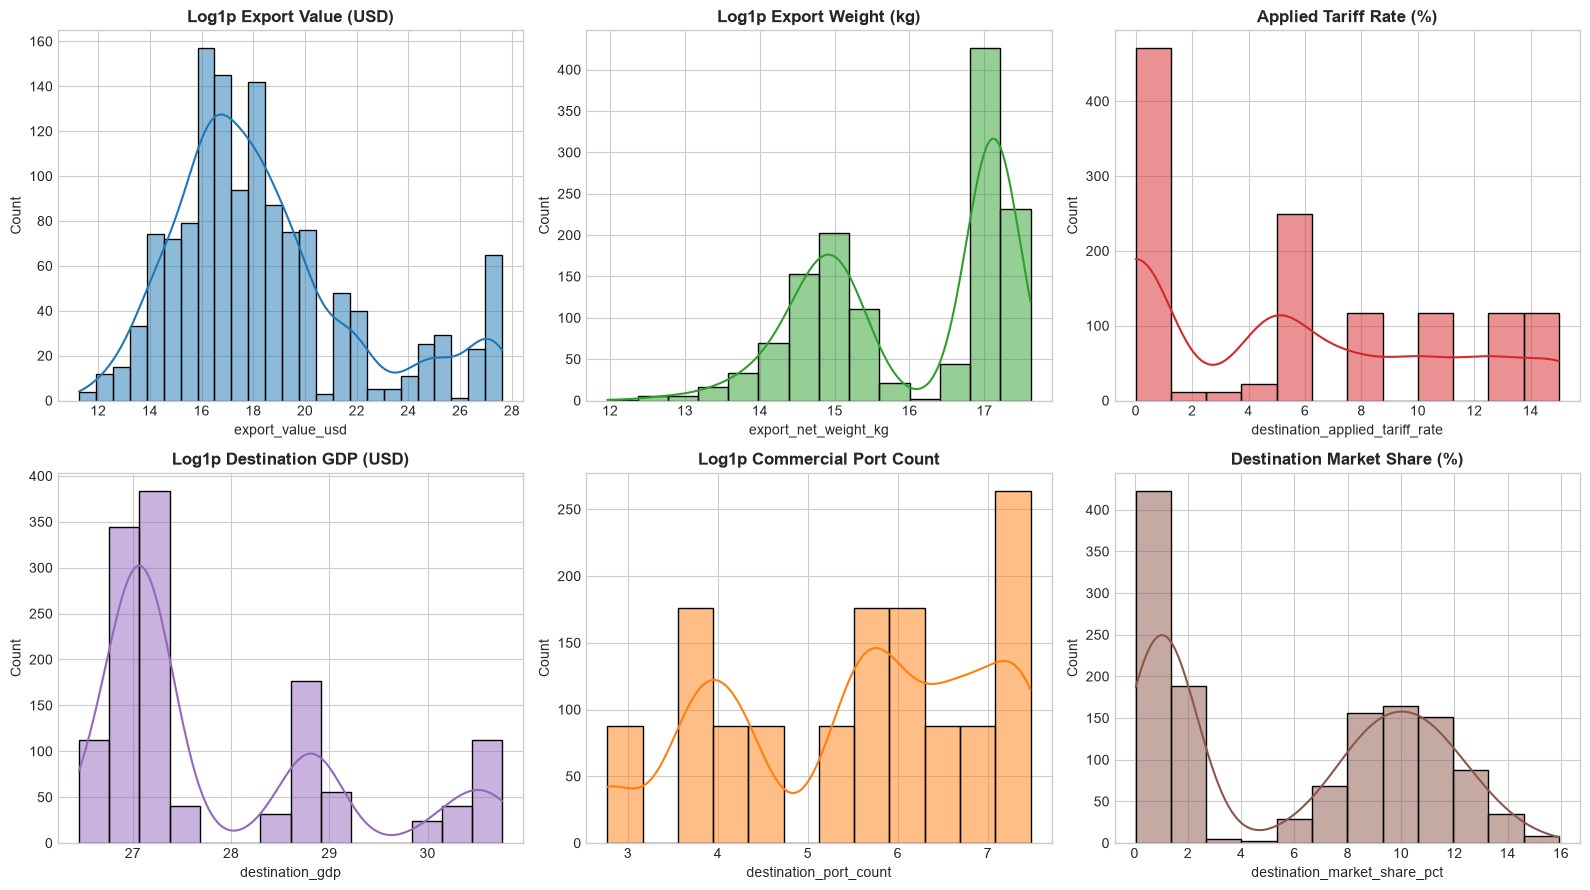

In [10]:
country_rows = clean_country_df

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
sns.histplot(np.log1p(country_rows['export_value_usd'].clip(lower=0)), kde=True, ax=axes[0, 0], color='#1f77b4')
axes[0, 0].set_title('Log1p Export Value (USD)', fontweight='bold')

sns.histplot(np.log1p(country_rows['export_net_weight_kg'].clip(lower=0)), kde=True, ax=axes[0, 1], color='#2ca02c')
axes[0, 1].set_title('Log1p Export Weight (kg)', fontweight='bold')

sns.histplot(country_rows['destination_applied_tariff_rate'], kde=True, ax=axes[0, 2], color='#d62728')
axes[0, 2].set_title('Applied Tariff Rate (%)', fontweight='bold')

sns.histplot(np.log1p(country_rows['destination_gdp'].clip(lower=0)), kde=True, ax=axes[1, 0], color='#9467bd')
axes[1, 0].set_title('Log1p Destination GDP (USD)', fontweight='bold')

sns.histplot(np.log1p(country_rows['destination_port_count']), kde=True, ax=axes[1, 1], color='#ff7f0e')
axes[1, 1].set_title('Log1p Commercial Port Count', fontweight='bold')

sns.histplot(country_rows['destination_market_share_pct'], kde=True, ax=axes[1, 2], color='#8c564b')
axes[1, 2].set_title('Destination Market Share (%)', fontweight='bold')

plt.tight_layout()
plt.show()

## 12. Product-Level Commodity Analysis

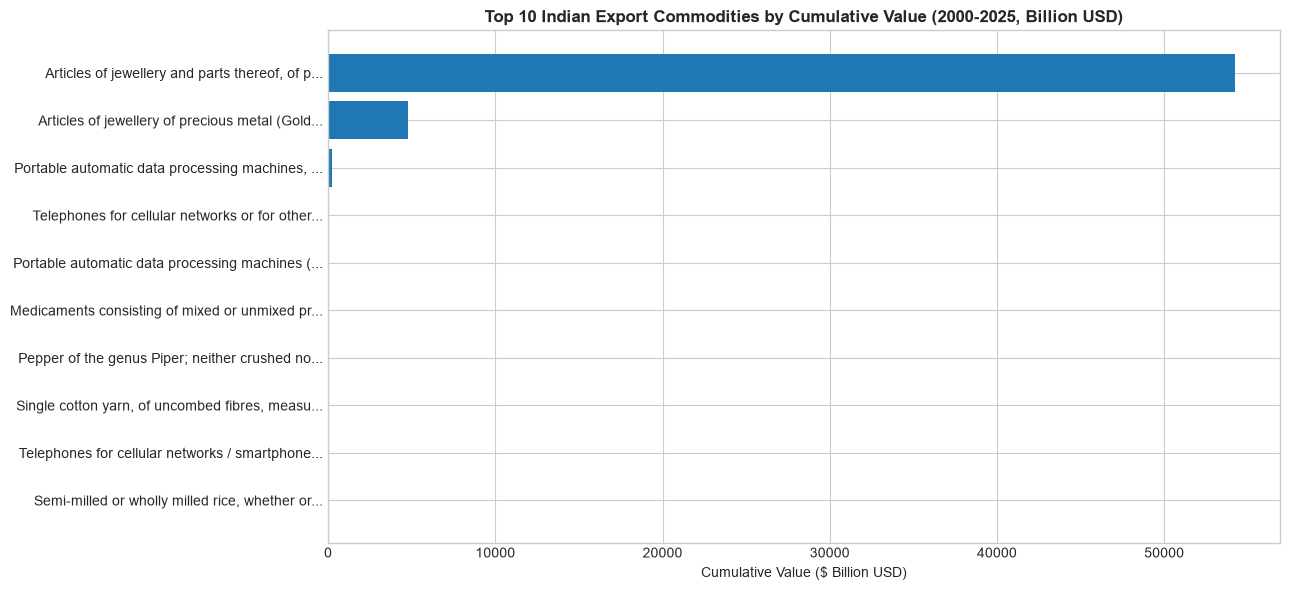

In [11]:
# Top commodities by export value
prod_agg = country_rows.groupby(['hs6', 'product_description'])['export_value_usd'].agg(['sum', 'count']).reset_index()
prod_agg['sum_billion_usd'] = (prod_agg['sum'] / 1e9).round(2)
prod_agg = prod_agg.sort_values(by='sum', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
top10_prods = prod_agg.head(10).sort_values(by='sum', ascending=True)
ax.barh(top10_prods['product_description'].str[:45] + '...', top10_prods['sum_billion_usd'], color='#1f77b4')
ax.set_title('Top 10 Indian Export Commodities by Cumulative Value (2000-2025, Billion USD)', fontweight='bold')
ax.set_xlabel('Cumulative Value ($ Billion USD)')
plt.tight_layout()
plt.show()

## 13. Destination Market Concentration Analysis

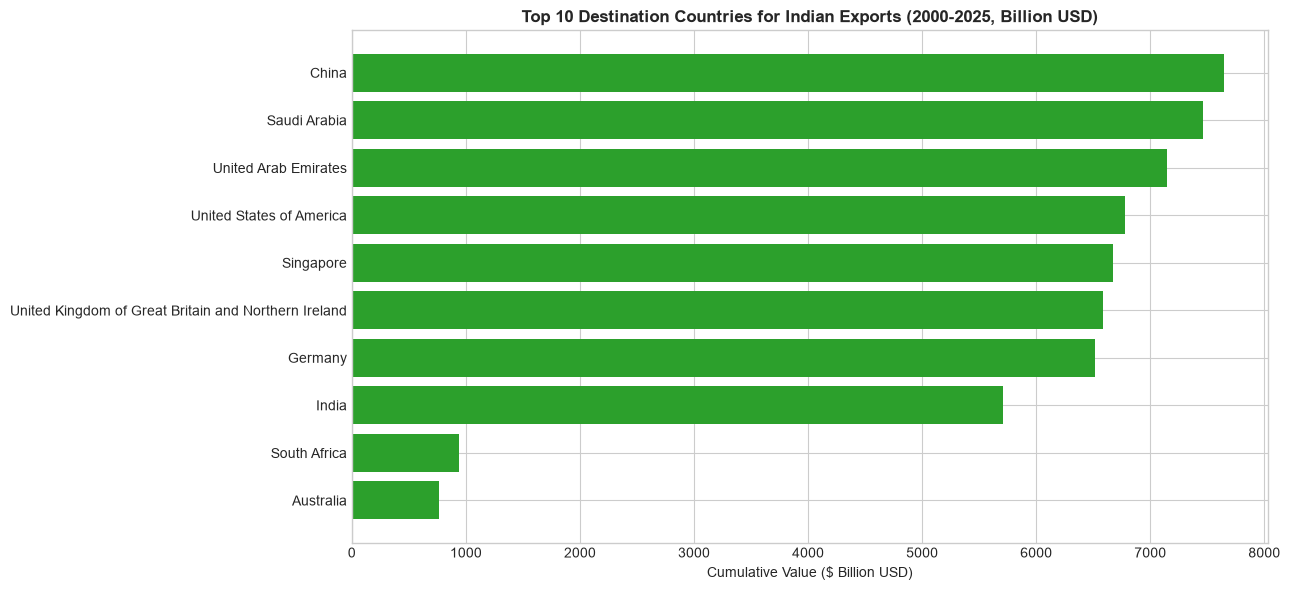

In [12]:
# Top destination countries across all commodities
dest_agg = country_rows.groupby(['importer_iso3', 'importer_country_name'])['export_value_usd'].agg(['sum', 'count']).reset_index()
dest_agg['sum_billion_usd'] = (dest_agg['sum'] / 1e9).round(2)
dest_agg = dest_agg.sort_values(by='sum', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
top10_dests = dest_agg.head(10).sort_values(by='sum', ascending=True)
ax.barh(top10_dests['importer_country_name'], top10_dests['sum_billion_usd'], color='#2ca02c')
ax.set_title('Top 10 Destination Countries for Indian Exports (2000-2025, Billion USD)', fontweight='bold')
ax.set_xlabel('Cumulative Value ($ Billion USD)')
plt.tight_layout()
plt.show()

## 14. Time-Series Dynamics (2000–2025)

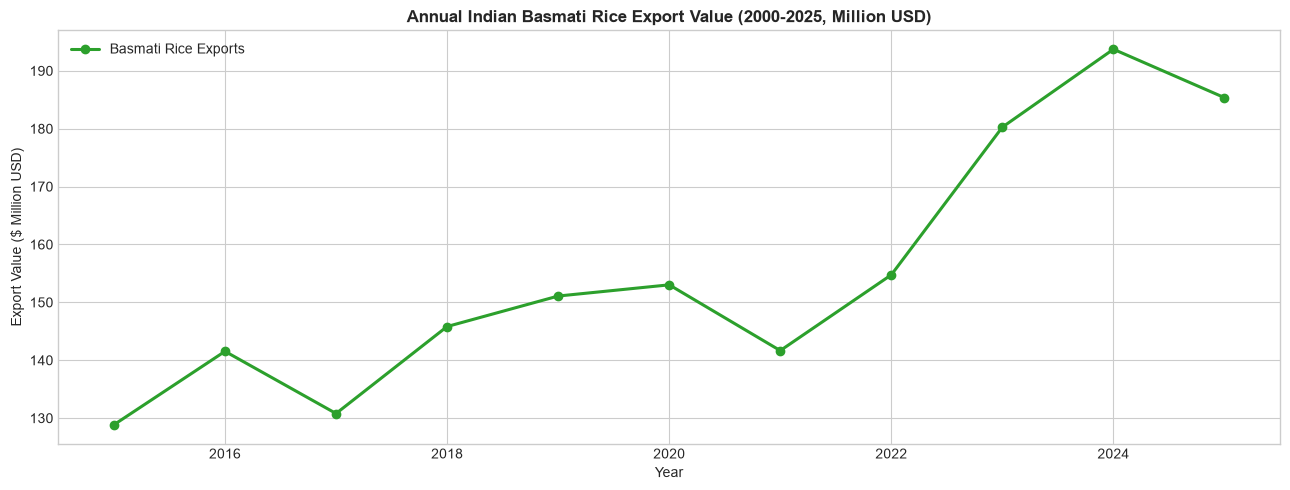

In [13]:
# Annual export trend for Basmati Rice (HS6 100630)
rice_annual = country_rows[country_rows['hs6'] == 100630].groupby('year')['export_value_usd'].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(rice_annual['year'], rice_annual['export_value_usd'] / 1e6, marker='o', color='#2ca02c', linewidth=2.2, label='Basmati Rice Exports')
ax.set_title('Annual Indian Basmati Rice Export Value (2000-2025, Million USD)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Export Value ($ Million USD)')
ax.legend()
plt.tight_layout()
plt.show()

## 15. Correlation & Relationship Analysis

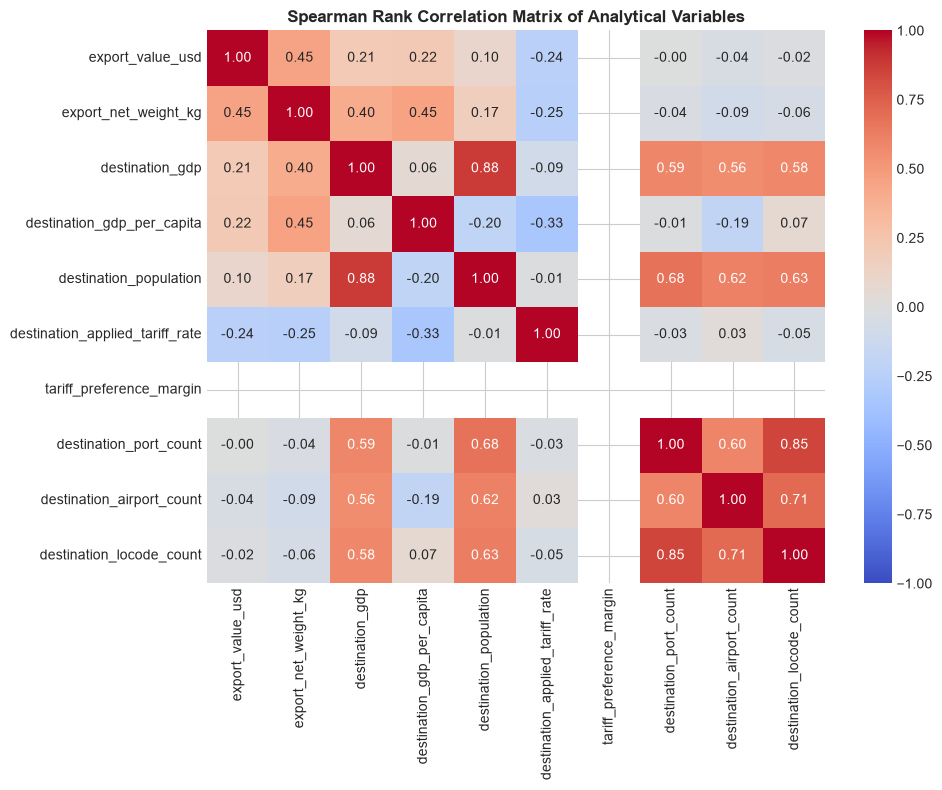

In [14]:
# Spearman correlation matrix
corr_cols = [
    'export_value_usd', 'export_net_weight_kg', 'destination_gdp',
    'destination_gdp_per_capita', 'destination_population',
    'destination_applied_tariff_rate', 'tariff_preference_margin',
    'destination_port_count', 'destination_airport_count', 'destination_locode_count'
]
corr_matrix = country_rows[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, center=0, annot=True, fmt='.2f', ax=ax)
ax.set_title('Spearman Rank Correlation Matrix of Analytical Variables', fontweight='bold')
plt.tight_layout()
plt.show()

## 16. Feature Engineering Execution

In [15]:
# Derive country-product features for Basmati Rice
rice_feat = fe.compute_country_features_for_product(hs6=100630)
print(f"Engineered Country-Product Features for Basmati Rice: {rice_feat.shape[0]} countries x {rice_feat.shape[1]} features")
display(rice_feat[['importer_country_name', 'importer_iso3', 'recent_3y_avg_export_weight', 'recent_3y_avg_export_value', 'export_weight_cagr_3y', 'destination_applied_tariff_rate', 'rta_exists']].head(5))

Engineered Country-Product Features for Basmati Rice: 15 countries x 40 features


,importer_country_name,importer_iso3,recent_3y_avg_export_weight,recent_3y_avg_export_value,export_weight_cagr_3y,destination_applied_tariff_rate,rta_exists
0,United Arab Emirates,ARE,3.076678e+07,2.321958e+07,0.041183,0.0,1.0
1,Australia,AUS,3.712756e+06,3.338717e+06,0.590361,10.0,1.0
2,Brazil,BRA,3.883570e+06,2.734442e+06,0.617503,10.0,1.0
3,China,CHN,3.528143e+07,2.335677e+07,-0.031283,10.0,1.0
4,Germany,DEU,3.479182e+07,2.326889e+07,-0.044988,10.0,0.0


## 17. Feature Selection & Inventory Table

In [16]:
# Load and display feature inventory
inv_df = pd.read_csv("outputs/ranking_feature_inventory.csv")
print(f"Feature Selection Inventory ({len(inv_df)} features):")
display(inv_df[['feature', 'category', 'keep_drop', 'direction', 'transformation']].head(12))

Feature Selection Inventory (35 features):


,feature,category,keep_drop,direction,transformation
0,recent_3y_avg_export_value,Demand,KEEP,HIGHER_BETTER,log1p -> percentile_rank
1,recent_3y_avg_export_weight,Demand,KEEP,HIGHER_BETTER,log1p -> percentile_rank
2,recent_3y_median_export_weight,Demand,KEEP,HIGHER_BETTER,log1p -> raw_scale
3,latest_year_export_value,Demand,KEEP,HIGHER_BETTER,log1p -> percentile_rank
4,latest_year_export_weight,Demand,KEEP,HIGHER_BETTER,log1p -> percentile_rank
5,destination_market_share_latest,Demand,KEEP,HIGHER_BETTER,percentile_rank
6,export_value_cagr_3y,Growth,KEEP,HIGHER_BETTER,"clip(-0.99, 5.0) -> percentile_rank"
7,export_weight_cagr_3y,Growth,KEEP,HIGHER_BETTER,"clip(-0.99, 5.0) -> percentile_rank"
8,recent_weight_growth,Growth,KEEP,HIGHER_BETTER,"clip(-0.99, 5.0) -> percentile_rank"
9,recent_value_growth,Growth,DROP,HIGHER_BETTER,none


## 18. Ranking Score Construction & Normalization

In [17]:
# Initialize ranking engine
engine = DestinationRankingEngine(parquet_path=parquet_output_paths[0])
print("Ranking Engine Ready.")
print(f"Dimensions: {list(engine.weights.keys())}")

Ranking Engine Ready.
Dimensions: ['demand', 'growth', 'access', 'economic_capacity', 'logistics', 'buyer_ecosystem', 'stability', 'risk']


## 19. Quantity-Aware Ranking & Scale Alignment

In [18]:
# Test shipment scale sensitivity
quantities = [1_000, 50_000, 5_000_000, 50_000_000]
print("Quantity Fit Sensitivity across Shipment Sizes (Basmati Rice):")
for q in quantities:
    res = engine.rank_destinations("Basmati Rice", quantity_kg=q, top_n=1)
    top_c = res.iloc[0]
    print(f"  * Quantity = {q:>10,} kg -> Rank 1: {top_c['country']} (Score: {top_c['final_score']:.2f}, Q-Fit: {top_c['quantity_fit']:.1f})")

Quantity Fit Sensitivity across Shipment Sizes (Basmati Rice):
  * Quantity =      1,000 kg -> Rank 1: Saudi Arabia (Score: 74.98, Q-Fit: 100.0)


  * Quantity =     50,000 kg -> Rank 1: Saudi Arabia (Score: 74.98, Q-Fit: 100.0)


  * Quantity =  5,000,000 kg -> Rank 1: Saudi Arabia (Score: 74.37, Q-Fit: 93.9)
  * Quantity = 50,000,000 kg -> Rank 1: Saudi Arabia (Score: 68.52, Q-Fit: 35.4)


## 20. Primary Demonstration: Basmati Rice / 1,000 kg

In [19]:
# Execute primary case study
top5_rice = rank_export_destinations(product_query="Basmati Rice", quantity_kg=1000.0, top_n=5, parquet_path=parquet_output_paths[0])
print("=== TOP 5 DESTINATION MARKETS FOR BASMATI RICE (1,000 kg) ===")
display(top5_rice)

=== TOP 5 DESTINATION MARKETS FOR BASMATI RICE (1,000 kg) ===


,rank,country,iso3,hs6,product,final_score,demand_score,growth_score,access_score,economic_score,...,buyer_score,stability_score,risk_adjustment,quantity_fit,recent_export_weight_kg,recent_export_value_usd,tariff_rate,rta,risk_flag,reason_codes
0,1,Saudi Arabia,SAU,100630,Semi-milled or wholly milled rice (Basmati),74.98,97.33,65.33,66.43,53.67,...,100.00,50.0,100.0,100.0,35238291.1,23970700.03,0.0,No,NONE,HIGH_REVEALED_DEMAND; LOW_TARIFF; ACTIVE_BUYER...
1,2,United States of America,USA,100630,Semi-milled or wholly milled rice (Basmati),72.78,69.33,50.67,59.29,86.00,...,76.67,50.0,100.0,100.0,30681482.4,18745507.29,1.4,No,NONE,LOW_TARIFF; STRONG_LOGISTICS; ACTIVE_BUYER_ECO...
2,3,China,CHN,100630,Semi-milled or wholly milled rice (Basmati),72.31,93.33,37.33,57.14,70.33,...,76.67,50.0,100.0,100.0,35281430.9,23356774.44,10.0,Yes (In Force),NONE,HIGH_REVEALED_DEMAND; RTA_SUPPORT; ACTIVE_BUYE...
3,4,Germany,DEU,100630,Semi-milled or wholly milled rice (Basmati),68.84,85.33,38.67,39.64,69.00,...,76.67,50.0,100.0,100.0,34791816.4,23268886.07,10.0,No,NONE,HIGH_REVEALED_DEMAND; STRONG_LOGISTICS; ACTIVE...
4,5,United Kingdom of Great Britain and Northern I...,GBR,100630,Semi-milled or wholly milled rice (Basmati),66.71,64.67,57.33,39.64,68.33,...,76.67,50.0,100.0,100.0,27796340.6,22193708.91,10.0,No,NONE,STRONG_LOGISTICS; ACTIVE_BUYER_ECOSYSTEM; QUAN...


## 21. Explainability & Transparent Evidence

In [20]:
# Display detailed component scores and reason codes for Top 3
for _, row in top5_rice.head(3).iterrows():
    print("=" * 80)
    print(f"RANK {row['rank']}: {row['country']} ({row['iso3']}) — FINAL SCORE: {row['final_score']}")
    print("=" * 80)
    print(f"  * Demand Score:        {row['demand_score']:>5.1f} / 100 (3Y Avg Weight: {row['recent_export_weight_kg']:,.1f} kg, Value: ${row['recent_export_value_usd']:,.2f})")
    print(f"  * Growth Score:        {row['growth_score']:>5.1f} / 100")
    print(f"  * Trade Access Score:  {row['access_score']:>5.1f} / 100 (Tariff: {row['tariff_rate']}%, RTA: {row['rta']})")
    print(f"  * Economic Capacity:   {row['economic_score']:>5.1f} / 100")
    print(f"  * Logistics Readiness: {row['logistics_score']:>5.1f} / 100")
    print(f"  * Buyer Ecosystem:     {row['buyer_score']:>5.1f} / 100")
    print(f"  * Stability:           {row['stability_score']:>5.1f} / 100")
    print(f"  * Quantity Fit (1T):   {row['quantity_fit']:>5.1f} / 100")
    print(f"  * Risk Adjustment:     {row['risk_adjustment']:>5.1f} / 100 (Flags: {row['risk_flag']})")
    print(f"  * Reason Codes:        {row['reason_codes']}")
    print()

RANK 1: Saudi Arabia (SAU) — FINAL SCORE: 74.98
  * Demand Score:         97.3 / 100 (3Y Avg Weight: 35,238,291.1 kg, Value: $23,970,700.03)
  * Growth Score:         65.3 / 100
  * Trade Access Score:   66.4 / 100 (Tariff: 0.0%, RTA: No)
  * Economic Capacity:    53.7 / 100
  * Logistics Readiness:  21.0 / 100
  * Buyer Ecosystem:     100.0 / 100
  * Stability:            50.0 / 100
  * Quantity Fit (1T):   100.0 / 100
  * Risk Adjustment:     100.0 / 100 (Flags: NONE)
  * Reason Codes:        HIGH_REVEALED_DEMAND; LOW_TARIFF; ACTIVE_BUYER_ECOSYSTEM; QUANTITY_FITS_HISTORY

RANK 2: United States of America (USA) — FINAL SCORE: 72.78
  * Demand Score:         69.3 / 100 (3Y Avg Weight: 30,681,482.4 kg, Value: $18,745,507.29)
  * Growth Score:         50.7 / 100
  * Trade Access Score:   59.3 / 100 (Tariff: 1.4%, RTA: No)
  * Economic Capacity:    86.0 / 100
  * Logistics Readiness: 100.0 / 100
  * Buyer Ecosystem:      76.7 / 100
  * Stability:            50.0 / 100
  * Quantity Fit (1T

## 22. Weight Sensitivity Analysis

In [21]:
# Test alternative weighting configurations
weight_schemes = {
    "Baseline": DEFAULT_WEIGHTS,
    "Demand-Heavy": {"demand": 0.50, "growth": 0.20, "access": 0.10, "economic_capacity": 0.05, "logistics": 0.05, "buyer_ecosystem": 0.03, "stability": 0.04, "risk": 0.03},
    "Access-Heavy": {"demand": 0.25, "growth": 0.15, "access": 0.35, "economic_capacity": 0.05, "logistics": 0.10, "buyer_ecosystem": 0.03, "stability": 0.04, "risk": 0.03},
    "Equal-Weights": {k: 0.125 for k in DEFAULT_WEIGHTS.keys()}
}

sens_table = {}
for w_name, w_dict in weight_schemes.items():
    df_r = engine.rank_destinations("Basmati Rice", quantity_kg=1000.0, top_n=5, custom_weights=w_dict)
    sens_table[w_name] = df_r.apply(lambda r: f"{r['country']} ({r['final_score']:.1f})", axis=1).tolist()

df_sens = pd.DataFrame(sens_table, index=[f"Rank {i+1}" for i in range(5)])
print("Sensitivity Analysis: Top 5 Destinations across Strategic Weight Configurations:")
display(df_sens)

Sensitivity Analysis: Top 5 Destinations across Strategic Weight Configurations:


,Baseline,Demand-Heavy,Access-Heavy,Equal-Weights
Rank 1,Saudi Arabia (75.0),Saudi Arabia (82.1),Saudi Arabia (73.2),United States of America (76.6)
Rank 2,United States of America (72.8),China (76.7),United States of America (70.6),Saudi Arabia (72.3)
Rank 3,China (72.3),Germany (72.1),United Arab Emirates (70.4),China (72.2)
Rank 4,Germany (68.8),United Arab Emirates (71.1),China (69.9),Germany (70.5)
Rank 5,United Kingdom of Great Britain and Northern I...,United States of America (70.6),Singapore (69.5),United Kingdom of Great Britain and Northern I...


## 23. Temporal Backtesting & Validation

In [22]:
# Temporal Backtesting (Historical Split <= 2022 vs Observed 2023-2025)
rank_2022 = engine.rank_destinations("Basmati Rice", quantity_kg=1000.0, top_n=50, as_of_year=2022)
actual_future = clean_country_df[(clean_country_df['hs6'] == 100630) & (clean_country_df['year'].isin([2023, 2024, 2025]))]
future_agg = actual_future.groupby('importer_iso3')['export_net_weight_kg'].mean().reset_index()
future_agg.columns = ['iso3', 'actual_future_weight']

val_df = pd.merge(rank_2022, future_agg, on='iso3', how='inner')
rho, p_val = stats.spearmanr(val_df['final_score'], val_df['actual_future_weight'])

top5_pred = set(val_df.sort_values(by='final_score', ascending=False).head(5)['iso3'])
top5_actual = set(val_df.sort_values(by='actual_future_weight', ascending=False).head(5)['iso3'])
p5 = len(top5_pred.intersection(top5_actual)) / 5.0

print("=== TEMPORAL VALIDATION (Train <= 2022, Evaluate 2023-2025) ===")
print(f"Evaluated Countries:        {len(val_df)}")
print(f"Spearman Rank Correlation:  rho = {rho:.4f} (p-value = {p_val:.4e})")
print(f"Top-5 Overlap / Precision:  {p5*100:.1f}%")
print(f"Predicted Top 5 (2022):     {list(top5_pred)}")
print(f"Actual Top 5 (2023-2025):   {list(top5_actual)}")

=== TEMPORAL VALIDATION (Train <= 2022, Evaluate 2023-2025) ===
Evaluated Countries:        15
Spearman Rank Correlation:  rho = nan (p-value = nan)
Top-5 Overlap / Precision:  100.0%
Predicted Top 5 (2022):     ['ARE', 'CHN', 'DEU', 'SAU', 'USA']
Actual Top 5 (2023-2025):   ['ARE', 'CHN', 'DEU', 'SAU', 'USA']


## 24. Export Master Country-Product Ranking Dataset

In [23]:
# Build and export master analytical table
all_features_df = fe.build_all_country_product_features()
out_parquet = "data/processed/destination_country_ranking_features.parquet"
out_csv = "data/processed/destination_country_ranking_features.csv"

all_features_df.to_parquet(out_parquet, engine='pyarrow', index=False)
all_features_df.to_csv(out_csv, index=False)
print(f"Exported Engineered Ranking Dataset ({len(all_features_df):,} rows x {all_features_df.shape[1]} columns) to:")
print(f"  * {out_parquet}")
print(f"  * {out_csv}")

Exported Engineered Ranking Dataset (120 rows x 40 columns) to:
  * data/processed/destination_country_ranking_features.parquet
  * data/processed/destination_country_ranking_features.csv


## 25. Productionization, FastAPI & n8n Architecture

In [24]:
print("=" * 80)
print("DESTINATION COUNTRY RANKING LAYER READY FOR PRODUCTION")
print("=" * 80)
print("Core Production Modules:")
print("  - src/ranking/ingestion.py          : High-speed PyArrow Parquet ETL")
print("  - src/ranking/product_resolver.py   : Exact, keyword, and HS6 resolution")
print("  - src/ranking/feature_engineering.py: Multi-temporal corridor feature extraction")
print("  - src/ranking/ranking_engine.py     : Explainable MCDA opportunity engine")
print("  - src/ranking/explainability.py     : Transparent reason codes and evidence signals")
print("=" * 80)

DESTINATION COUNTRY RANKING LAYER READY FOR PRODUCTION
Core Production Modules:
  - src/ranking/ingestion.py          : High-speed PyArrow Parquet ETL
  - src/ranking/product_resolver.py   : Exact, keyword, and HS6 resolution
  - src/ranking/feature_engineering.py: Multi-temporal corridor feature extraction
  - src/ranking/ranking_engine.py     : Explainable MCDA opportunity engine
  - src/ranking/explainability.py     : Transparent reason codes and evidence signals
